# **AI-BASED HIRING PREDICTION SYSTEM**

## **OBJECTIVE OF THE PROJECT**

The objective of this project is to develop a machine learning model that predicts whether a candidate will be **Hired** or **Rejected** based on resume information such as skills, education, experience, certifications, salary expectation, and projects. This project simulates an AI-powered resume screening system used in HR Analytics.

## **Import Libraries**

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## **Load Dataset**

In [35]:
df = pd.read_csv("AI based hiring prediction system.csv")

df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


## **Dataset Shape**

In [36]:
df.shape

(1000, 11)

## **Dataset Information**

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


## **Missing Values**

In [38]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


## **Duplicate Rows**

In [39]:
df.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis**

## **Statistical Summary**

In [40]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


## **Target Variable**

In [41]:
df["Recruiter Decision"].value_counts()

,count
Recruiter Decision,
Hire,812
Reject,188


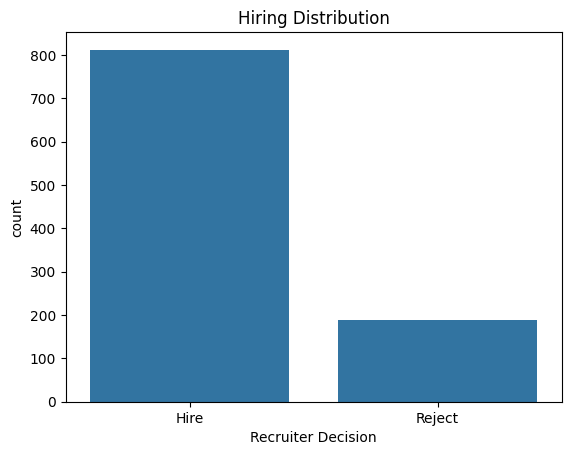

In [42]:
sns.countplot(x="Recruiter Decision",data=df)
plt.title("Hiring Distribution")
plt.show()

## **Education Distribution**

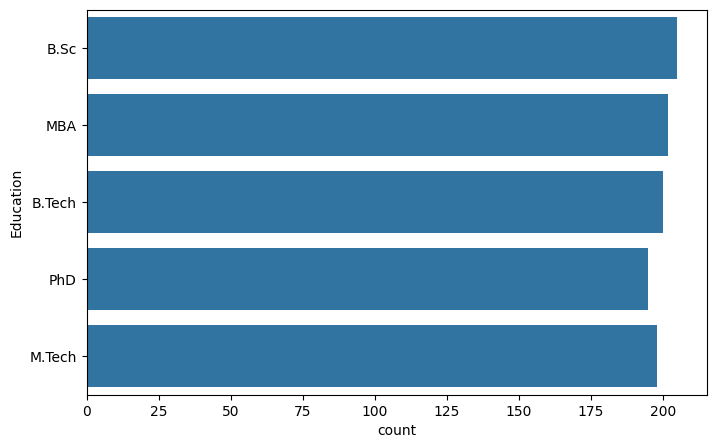

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(y="Education",data=df)
plt.show()

## **Job Role Distribution**

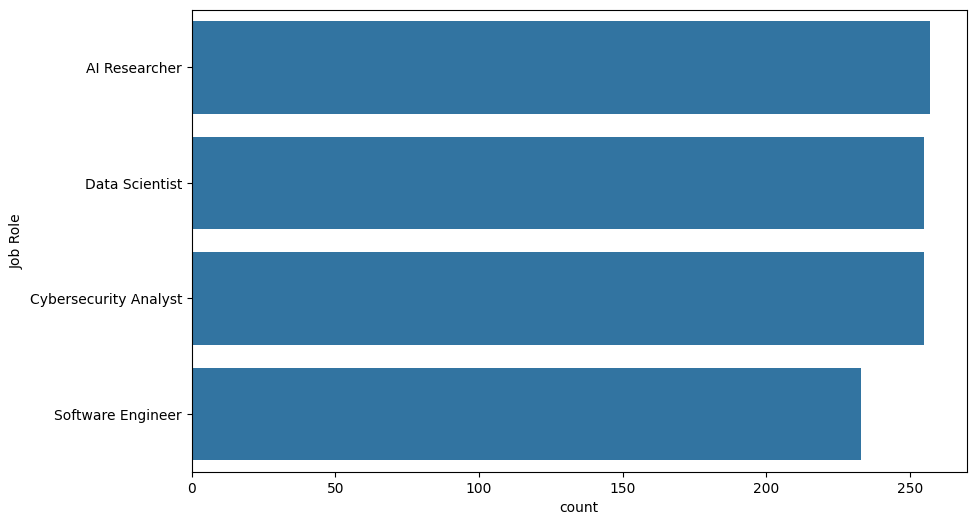

In [44]:
plt.figure(figsize=(10,6))
sns.countplot(y="Job Role",data=df)
plt.show()

## **Experience Distribution**

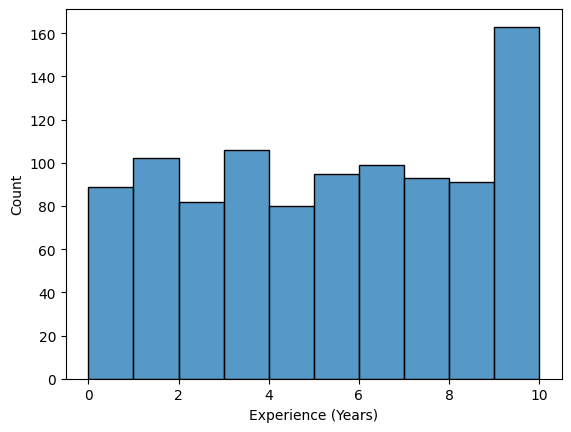

In [45]:
sns.histplot(df["Experience (Years)"],bins=10)
plt.show()

## **Salary Distribution**

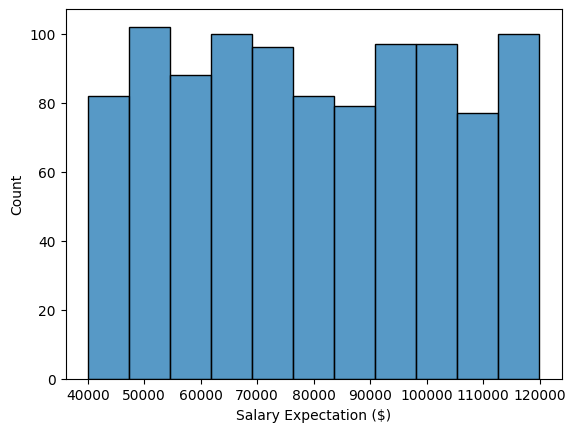

In [46]:
sns.histplot(df["Salary Expectation ($)"])
plt.show()

## **Data Preprocessing**
Data preprocessing is an essential step in the machine learning workflow. It involves transforming raw data into a clean, structured, and machine-readable format before training the model. Since machine learning algorithms cannot directly process textual or inconsistent data, preprocessing helps improve the quality of the dataset and enhances the model's performance.

In [47]:
df.drop(["Resume_ID","Name"],axis=1,inplace=True)

## **Convert Skills into Numerical**

In [48]:
df["Skills"] = df["Skills"].astype(str)

## **Label Encoding**
Label Encoding is a preprocessing technique that assigns a unique integer to each unique category in a feature.

In [49]:
le=LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=le.fit_transform(df[col])

In [50]:
df.head()

,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,226,10,0,3,0,0,104895,8,100
1,32,10,3,2,2,0,113002,1,100
2,46,1,3,1,1,0,71766,7,70
3,152,7,1,0,0,0,46848,0,95
4,221,4,4,3,3,0,87441,9,100


## **Correlation Heatmap**

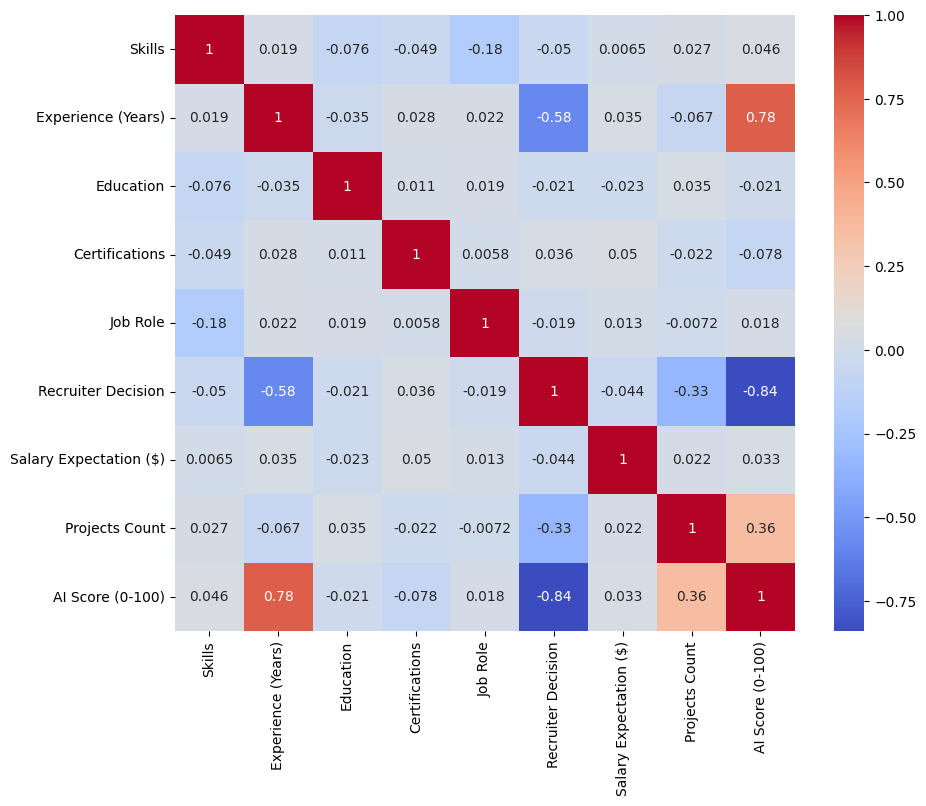

In [51]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

## **Split Dataset**

In [52]:
X=df.drop("Recruiter Decision",axis=1)
y=df["Recruiter Decision"]

In [78]:
X = df.drop("Recruiter Decision", axis=1)
y = df["Recruiter Decision"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# **Model Building**

## **Random Forest**

In [54]:
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

### **Prediction**

In [57]:
y_pred=rf.predict(X_test)

### **Accuracy**

In [56]:
accuracy_score(y_test,y_pred)

1.0

### **Classification Report**

In [58]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



### **Confusion matrix**

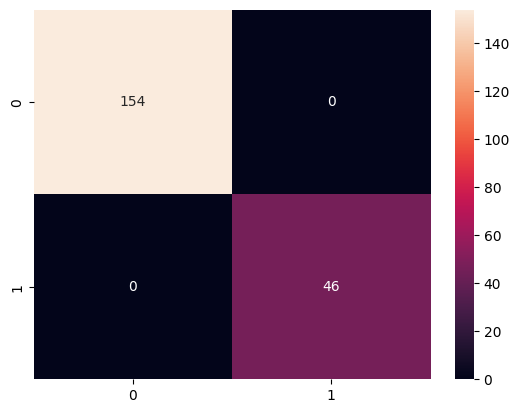

In [59]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d')
plt.show()

## **Feature Importance**

In [60]:
importance=pd.DataFrame({
"Feature":X.columns,
"Importance":rf.feature_importances_
})
importance.sort_values("Importance",ascending=False)

,Feature,Importance
7,AI Score (0-100),0.650045
1,Experience (Years),0.211973
6,Projects Count,0.076600
5,Salary Expectation ($),0.021088
0,Skills,0.020668
3,Certifications,0.008680
2,Education,0.005643
4,Job Role,0.005302


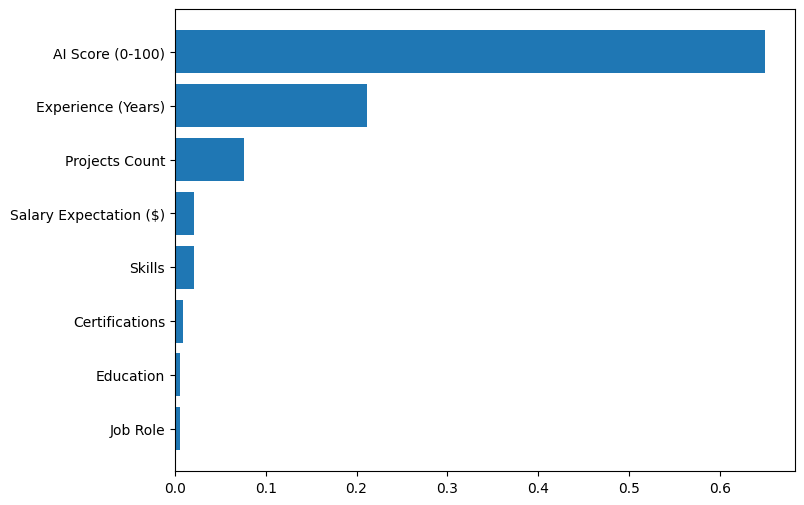

In [61]:
importance=importance.sort_values("Importance",ascending=True)
plt.figure(figsize=(8,6))
plt.barh(
importance["Feature"],
importance["Importance"]
)
plt.show()

## **Testing on new candidate**

In [82]:
new_candidate = pd.DataFrame({
    'Skills': [1],
    'Experience (Years)': [5],
    'Education': [3],
    'Certifications': [1],
    'Job Role': [1],
    'Salary Expectation ($)': [71766],
    'Projects Count': [7],
    'AI Score (0–100)': [70]
})

In [84]:
if 'AI Score (0–100)' in new_candidate.columns:
    new_candidate.rename(columns={'AI Score (0–100)': 'AI Score (0-100)'}, inplace=True)

prediction = rf.predict(new_candidate)

if prediction[0] == 1:
    print("Candidate is likely to be Hired ✅")
else:
    print("Candidate is likely to be Rejected ❌")

Candidate is likely to be Rejected ❌


## **Conclusion**


Built an AI-Based Hiring Prediction System capable of predicting whether a candidate will be hired or rejected using resume features. The Random Forest model achieved high accuracy and identified the most influential factors such as experience, skills, certifications, and projects.